In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
perch_full = pd.read_csv("https://bit.ly/perch_csv_data")

In [3]:
perch = perch_full.copy()

In [4]:
perch.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [5]:
perch_weight = np.array(
    [
        5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0,
    ]
)

In [6]:
train_input, test_input, train_target, test_target = train_test_split(perch, perch_weight, random_state=42)

In [7]:
poly  = PolynomialFeatures(include_bias=False)

In [8]:
poly.fit([[2, 3]])

PolynomialFeatures(include_bias=False)

In [9]:
print(poly.transform([[2, 3]]))

[[2. 3. 4. 6. 9.]]


In [10]:
poly  = PolynomialFeatures(include_bias=False)

In [11]:
poly.fit(train_input)

PolynomialFeatures(include_bias=False)

In [12]:
train_poly = poly.transform(train_input)

In [13]:
print(train_poly.shape)

(42, 9)


In [14]:
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [15]:
test_poly = poly.transform(test_input)

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(train_poly, train_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 34.81, -88.68,-184.12,..., 27.76,-119.89, 93.68]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,124.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[3630.41, 134.86, 60.33,..., 0.63, 0.43, 0.26]"


In [18]:
lr.score(train_poly, train_target)

0.9903183436982125

In [19]:
lr.score(test_poly, test_target)

0.9714559911594169

In [20]:
poly = PolynomialFeatures(degree = 18, include_bias=False)

In [21]:
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [22]:
print(train_poly.shape)

(42, 1329)


In [23]:
lr.fit(train_poly, train_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1329,)","[-0.,-0.,-0.,..., 0., 0., 0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,166
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1329
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](42,)","[5.53e+29,5.36e+27,2.50e+27,...,1.32e+14,6.14e+13,6.14e+13]"


In [24]:
lr.score(train_poly, train_target)

0.9301920453686103

In [25]:
lr.score(test_poly, test_target)

-2.3824120969245084

In [26]:
ss = StandardScaler()

In [27]:
ss.fit(train_poly)

StandardScaler()

In [28]:
train_scaled = ss.transform(train_poly)

In [29]:
test_scaled = ss.transform(test_poly)

In [30]:
ridge = Ridge()
ridge.fit(train_scaled, train_target)
ridge.score(train_scaled, train_target)

0.9958147936113382

In [31]:
ridge.score(test_scaled, test_target)

0.9941046509169043

In [32]:
train_score = []
test_score = []

In [33]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

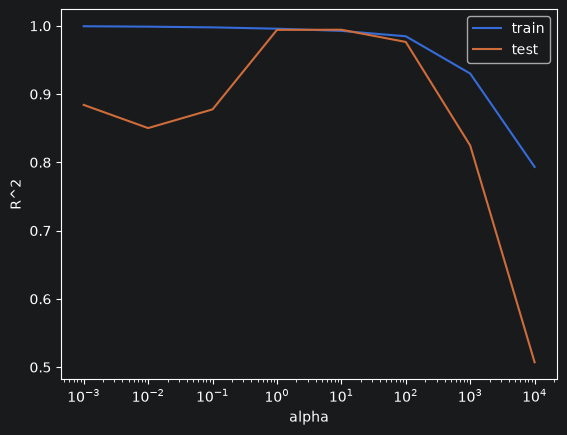

In [34]:
plt.plot(alpha_list, train_score, label = 'train')
plt.plot(alpha_list, test_score, label = 'test')
plt.legend()
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [35]:
ridge = Ridge(alpha=100)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9847433236035403
0.9764061651977075


In [36]:
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.9926194596089876


In [37]:
print(lasso.score(test_scaled, test_target))

0.9962099605899388


In [38]:
train_score = []
test_score = []

In [39]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

/Users/samoyed/Documents/Study/ML-Study/Machine-Learning/Study/Hands-On-Machine-learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.666121e+03, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/Users/samoyed/Documents/Study/ML-Study/Machine-Learning/Study/Hands-On-Machine-learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.448959e+03, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


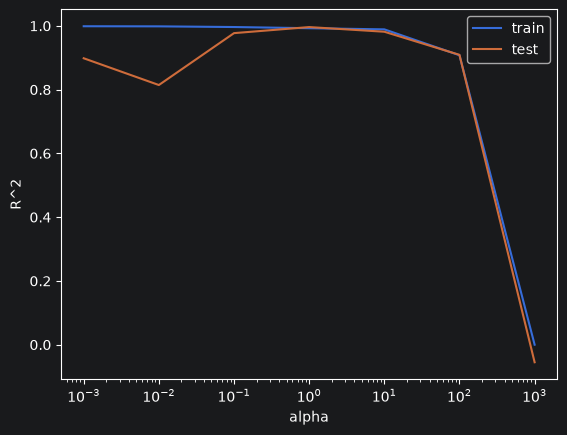

In [40]:
plt.plot(alpha_list, train_score, label = 'train')
plt.plot(alpha_list, test_score, label = 'test')
plt.legend()
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [43]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9889316347433115
0.9816548968656196


In [44]:
np.sum(lasso.coef_ == 0)

np.int64(1312)